# 01 — Data Exploration


In [9]:
## Set up to load data already process in disk


import geopandas as gpd
import pandas as pd
import folium
import branca.colormap as cm

gdf_merged   = gpd.read_file("data/processed/gdf_merged.geojson")
df_bikes     = pd.read_csv("data/processed/bikes.csv")

# Rebuild what we need from GTFS (already on disk)
df_stops_only = pd.read_csv("data/processed/rail_stops.csv")
df_routes     = pd.read_csv("data/raw/gtfs_rail/routes.txt")
df_shapes     = pd.read_csv("data/raw/gtfs_rail/shapes.txt")
df_trips      = pd.read_csv("data/raw/gtfs_rail/trips.txt")

# Rebuild shape_to_route join
shape_to_route = df_trips[['route_id','shape_id']].drop_duplicates()
shape_to_route = shape_to_route.merge(
    df_routes[['route_id','route_long_name','route_color']], on='route_id'
)

print(f"Tracts:        {len(gdf_merged)}")
print(f"Bike stations: {len(df_bikes)}")
print(f"Rail stops:    {len(df_stops_only)}")
print(f"Slope column:  {'slope_mean' in gdf_merged.columns}")

Tracts:        2498
Bike stations: 225
Rail stops:    111
Slope column:  True


In [22]:
## Raster analysis for slope 

import numpy as np
import rioxarray as rxr
import rasterio
from rasterstats import zonal_stats
from io import BytesIO


# Load the saved slope raster we calculated last session
# No recalculation needed — just read from disk
stats = zonal_stats(
    gdf_merged.to_crs("EPSG:4326"),      # make sure CRS matches
    "data/processed/la_slope.tif",
    stats=["mean", "median", "max"],
    nodata=-9999
)

df_slope = pd.DataFrame(stats)
df_slope.columns = ['slope_max', 'slope_mean', 'slope_median']

gdf_merged['slope_mean']   = df_slope['slope_mean'].values
gdf_merged['slope_median'] = df_slope['slope_median'].values
gdf_merged['slope_max']    = df_slope['slope_max'].values

print(gdf_merged[['GEOID', 'slope_mean', 'slope_median', 'slope_max']].head(5))
print(f"Nulls: {gdf_merged['slope_mean'].isna().sum()}")

# Overwrite the saved file with slope columns included
gdf_merged.to_file("data/processed/gdf_merged.geojson", driver="GeoJSON")
print("gdf_merged saved with slope columns")

gdf_merged['slope_mean']   = gdf_merged['slope_mean'].round(3)
gdf_merged['slope_median'] = gdf_merged['slope_median'].round(3)
gdf_merged['slope_max']    = gdf_merged['slope_max'].round(3)

         GEOID  slope_mean  slope_median  slope_max
0  06037137504   15.517113     14.071072  39.831318
1  06037138000   12.636160     12.267635  31.354460
2  06037139200    1.820609      1.747791   3.787437
3  06037143200    1.778921      1.720832   4.843591
4  06037201301    9.382747      8.896590  24.987738
Nulls: 3
gdf_merged saved with slope columns


In [3]:
## GTFS Data
## More explaration to be later done.
df_stops   = pd.read_csv("data/raw/gtfs_rail/stops.txt")
df_routes  = pd.read_csv("data/raw/gtfs_rail/routes.txt")
df_shapes  = pd.read_csv("data/raw/gtfs_rail/shapes.txt")
df_trips   = pd.read_csv("data/raw/gtfs_rail/trips.txt")

# Join shapes to routes via trips
shape_to_route = df_trips[['route_id', 'shape_id']].drop_duplicates()
shape_to_route = shape_to_route.merge(
    df_routes[['route_id', 'route_long_name', 'route_color']],
    on='route_id'
)

# Filter actual stops only
df_stops_only = df_stops[df_stops['location_type'] == 0]

print(f"Rail stops: {len(df_stops_only)}")
print(f"Routes: {len(df_routes)}")

# Bus stops
df_bus_stops = pd.read_csv("data/raw/gtfs_bus/stops.txt")
print(f"Bus stops: {len(df_bus_stops)}")

Rail stops: 111
Routes: 6
Bus stops: 11881


In [11]:
#  Map
# Visualizes census demographics layered with transit and bikes

from branca.colormap import LinearColormap

# --- BASE MAP ---
# CartoDB positron = clean, light, minimal basemap — NYT style
# zoom_start=10 shows all of LA County at once

m = folium.Map(
    location=[34.0522, -118.2437],  # center of LA
    zoom_start=10,
    tiles="CartoDB positron"
)

# --- CLEAN THE DATA ---
# Drop tracts where income is 0 or negative
# These are Census artifacts — unpopulated areas, parks, airports
gdf_map = gdf_merged[gdf_merged['median_income'] > 0].copy()

# --- BUILD COLOR SCALE ---
# LinearColormap maps a value range to a list of colors
# We use quantiles (0.05, 0.95) instead of min/max
# to avoid extreme outliers skewing the entire color scale
# Red = low income, Blue = high income
colormap = LinearColormap(
    colors=['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4'],
    vmin=gdf_map['median_income'].quantile(0.05),  # 5th percentile as floor
    vmax=gdf_map['median_income'].quantile(0.95),  # 95th percentile as ceiling
    caption='Median Household Income ($)'          # legend label
)

# --- CHOROPLETH LAYER: Census Tracts ---
# GeoJson renders each polygon with a style based on its properties
# style_function runs once per feature — it receives the GeoJSON feature
# and returns a dict of CSS-like style properties

folium.GeoJson(
    gdf_map,
    name="Median Income",
    style_function=lambda feature: {
        # colormap() converts a number to a hex color
        # the 'if' guard handles any remaining None values
        'fillColor': colormap(feature['properties']['median_income'])
            if feature['properties']['median_income'] else '#gray',
        'color': 'white',       # polygon border color
        'weight': 0.3,          # border thickness — thin keeps it clean
        'fillOpacity': 0.7      # slightly transparent so basemap shows through
    },
    # tooltip appears on hover — fields must exist in gdf_map columns
    # aliases = human readable labels shown in the tooltip
tooltip=folium.GeoJsonTooltip(
    fields=['NAME_y', 'median_income', 'pct_no_vehicle', 'pct_transit'],
    aliases=['Tract', 'Median Income ($)', 'No Vehicle (%)', 'Transit Commuters (%)'],
    localize=True
)
).add_to(m)

# Add the color legend to the map
colormap.add_to(m)

# --- RAIL LINES in Metro colors ---
# FeatureGroup lets us toggle this layer independently
rail_layer = folium.FeatureGroup(name="Rail Lines", show=True)
for _, shape_row in shape_to_route.iterrows():
    shape_id = shape_row['shape_id']
    color    = f"#{shape_row['route_color']}"  # color comes from routes.txt

    # Get all points for this shape, sorted by sequence
    # then convert to list of [lat, lon] pairs for PolyLine
    points = df_shapes[df_shapes['shape_id'] == shape_id]\
        .sort_values('shape_pt_sequence')[['shape_pt_lat', 'shape_pt_lon']]\
        .values.tolist()

    if points:  # guard against empty shapes
        folium.PolyLine(
            points,
            color=color,
            weight=4,
            opacity=0.9,
            tooltip=shape_row['route_long_name']  # hover shows line name
        ).add_to(rail_layer)
rail_layer.add_to(m)

# --- BIKE SHARE STATIONS ---
bike_layer = folium.FeatureGroup(name="Bike Share", show=True)
for _, row in df_bikes.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color='#E63946',   # red accent — stands out against blue choropleth
        fill=True,
        fill_opacity=0.8,
        # popup appears on click — shows live availability
        popup=folium.Popup(
            f"<b>{row['name']}</b><br>"
            f"Bikes: {row['num_bikes_available']}<br>"
            f"Docks: {row['num_docks_available']}",
            max_width=200
        )
    ).add_to(bike_layer)
bike_layer.add_to(m)

# --- BUS STOPS ---
# show=False means this layer is off by default
# Very subtle styling — just coverage context, not the focus
bus_layer = folium.FeatureGroup(name="Bus Stops", show=False)
for _, row in df_bus_stops.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=1,
        color='#AAAAAA',
        fill=True,
        fill_opacity=0.3
    ).add_to(bus_layer)
bus_layer.add_to(m)

# --- LAYER CONTROL ---
# collapsed=False keeps the panel open by default
# Each FeatureGroup appears as a toggle in the panel
folium.LayerControl(collapsed=False).add_to(m)

# --- SAVE ---
m.save("data/processed/map_v4.html")
print("Map v4 saved")



Map v4 saved


## OSM Section

In [ ]:
# Save gdf_merged as GeoJSON (preserves geometry + all columns)
gdf_merged.to_file("data/processed/gdf_merged.geojson", driver="GeoJSON")

# Save df_bikes as CSV (no geometry needed)
df_bikes.to_csv("data/processed/bikes.csv", index=False)

# Save rail stops as CSV
df_stops_only.to_csv("data/processed/rail_stops.csv", index=False)

df_census.to_csv("data/processed/census.csv", index=False)

print("All processed data saved")
print(f"  gdf_merged: {len(gdf_merged)} tracts")
print(f"  df_bikes:   {len(df_bikes)} stations")
print(f"  rail stops: {len(df_stops_only)} stops")
print(f"census: {len(df_census)} tracts")


## Working with OSM data


In [13]:
# Fetches OSM bike lanes 

import osmnx as ox
bike_lanes = ox.features_from_place(
    "Los Angeles County, California, USA",
    tags={"highway": "cycleway"}   # dedicated bike paths
)

# Filter to lines only — nodes are just points, not useful for lanes
bike_lanes_osm = bike_lanes[bike_lanes.geometry.geom_type == "LineString"].copy()

# Keep only useful columns
bike_lanes_osm = bike_lanes_osm[["geometry", "highway", "name", "surface"]].reset_index()

print(f"OSM bike lines: {len(bike_lanes_osm)}")
print(bike_lanes_osm.head(3))

OSM bike lines: 3686
  element       id                                           geometry  \
0     way  4341140  LINESTRING (-118.44558 33.97005, -118.44554 33...   
1     way  4341259  LINESTRING (-118.48244 33.99653, -118.48236 33...   
2     way  4341259  LINESTRING (-118.48244 33.99653, -118.48236 33...   

    highway                    name   surface  
0  cycleway                     NaN     paved  
1  cycleway  Venice Beach Bike Path  concrete  
2  cycleway  Venice Beach Bike Path  concrete  


Text(0.5, 1.0, 'OSM Bike Infrastructure — LA County')

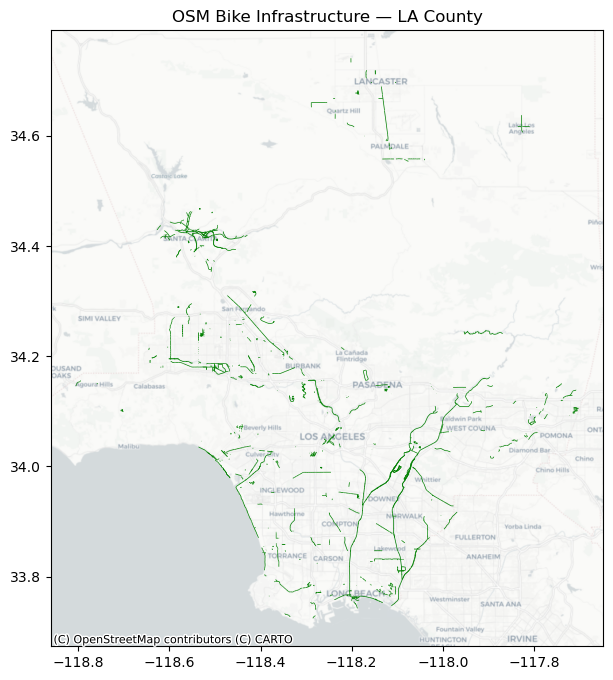

In [14]:
## Map visual
ax = bike_lanes_osm.plot(figsize=(10, 8), color='green', linewidth=0.5)

# contextily adds a basemap tile underneath
import contextily as ctx
ctx.add_basemap(ax, crs=bike_lanes_osm.crs.to_string(), source=ctx.providers.CartoDB.Positron)

ax.set_title("OSM Bike Infrastructure — LA County")

In [17]:
## Fetching bike lanes
print("Fetching bike lanes...")
bike_url = (
    "https://services1.arcgis.com/tp9wqSVX1AitKgjd/arcgis/rest/services/"
    "LA_City_Bikeways/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
)
response = requests.get(bike_url)
bike_lanes_la = gpd.read_file(BytesIO(response.content))
print(f"LA bike lanes: {len(bike_lanes_la)} features")
print(bike_lanes_la.columns.tolist())



Fetching bike lanes...
LA bike lanes: 1000 features
['OBJECTID', 'ASSETID', 'SECT_ID', 'flag', 'InputDate', 'Update_Date', 'Install_Da', 'FY', 'Year_', 'ST_NAME', 'ST_FROM', 'ST_TO', 'Comments', 'Limits', 'Class', 'Project_Name', 'Bikeway', 'Project_Type', 'RetireType', 'Retire', 'Upgraded_From', 'ST_TYPE', 'STREET_DES', 'ST_WIDTH', 'CL_Miles', 'Lane_Miles', 'CD', 'Network', 'Region', 'One_Dir_BW', 'CHECKED', 'Tag', 'OTHER', 'MP2035_Network', 'INTERU_FLAG', 'ClassIV_Protection', 'ClassIV_Protection_Notes', 'ClassIV_Protection_Type', 'Compare', 'Bikeway_ID', 'GlobalID', 'Shape__Length', 'geometry']


In [29]:
import branca.colormap as cm

# Anchor colormap to our known bikeability thresholds
# not quantiles — we want the colors to mean something specific
colormap_slope = cm.StepColormap(
    colors=['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'],
    # green=flat → yellow=moderate → red=steep
    index=[0, 3, 5, 8, 15, 42],   # breakpoints in slope %
    vmin=0, vmax=42,
    caption='Mean Slope'
)

m = folium.Map(location=[34.0522, -118.2437], zoom_start=10, tiles="CartoDB positron")

slope_layer = folium.FeatureGroup(name="Mean Slope per Tract", show=True)
folium.GeoJson(
    gdf_merged,
    style_function=lambda f: {
        'fillColor':   colormap_slope(f['properties']['slope_mean'] or 0),
        'fillOpacity': 0.4,
        'color':       'white',
        'weight':      0.2
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['slope_mean', 'slope_max', 'slope_category'],
        aliases=['Mean Slope %', 'Max Slope %', 'Category']
    )
).add_to(slope_layer)
slope_layer.add_to(m)
colormap_slope.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m.save("data/processed/map_slope.html")
print("Slope map saved")

Slope map saved


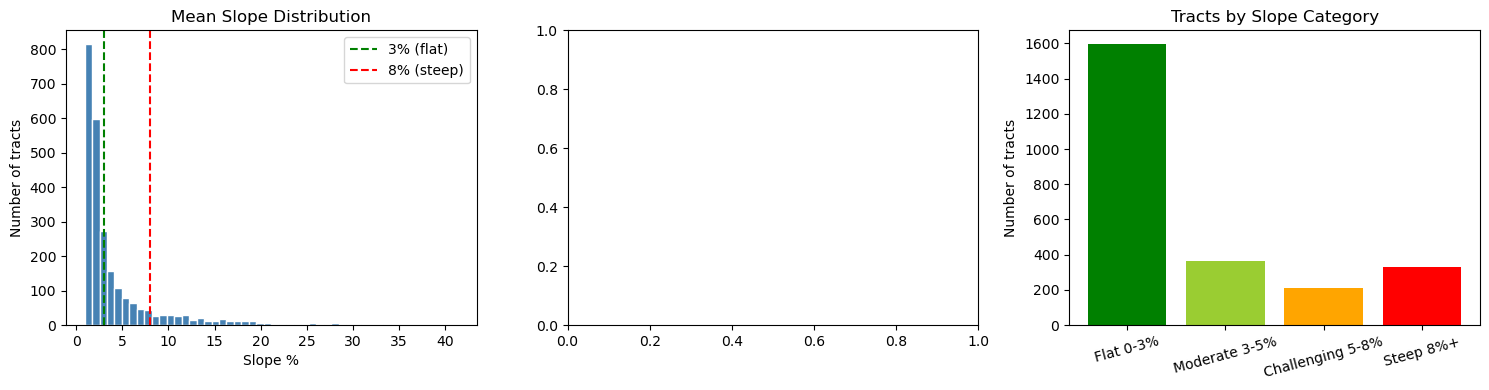

count    2495.00
mean        4.18
std         4.86
min         0.92
25%         1.56
50%         2.23
75%         4.35
max        41.38
Name: slope_mean, dtype: float64

Tracts per category:
slope_category
Flat 0-3%           1595
Moderate 3-5%        361
Challenging 5-8%     209
Steep 8%+            330
Name: count, dtype: int64


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution of mean slope
axes[0].hist(gdf_merged['slope_mean'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=3,  color='green',  linestyle='--', label='3% (flat)')
axes[0].axvline(x=8,  color='red',    linestyle='--', label='8% (steep)')
axes[0].set_title('Mean Slope Distribution')
axes[0].set_xlabel('Slope %')
axes[0].set_ylabel('Number of tracts')
axes[0].legend()


# What % of tracts fall in each bikeability category
bins   = [0, 3, 5, 8, 999]
labels = ['Flat 0-3%', 'Moderate 3-5%', 'Challenging 5-8%', 'Steep 8%+']
gdf_merged['slope_category'] = pd.cut(
    gdf_merged['slope_mean'], bins=bins, labels=labels
)
counts = gdf_merged['slope_category'].value_counts().sort_index()
axes[2].bar(counts.index, counts.values, color=['green','yellowgreen','orange','red'])
axes[2].set_title('Tracts by Slope Category')
axes[2].set_ylabel('Number of tracts')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Summary stats
print(gdf_merged['slope_mean'].describe().round(2))
print("\nTracts per category:")
print(counts)

In [25]:
print(f"Min slope:          {gdf_merged['slope_mean'].min():.1f}%")
print(f"Max slope:          {gdf_merged['slope_mean'].max():.1f}%")
print(f"Mean slope:         {gdf_merged['slope_mean'].mean():.1f}%")
print(f"Quantile 5%:        {gdf_merged['slope_mean'].quantile(0.05):.1f}%")
print(f"Quantile 95%:       {gdf_merged['slope_mean'].quantile(0.95):.1f}%")
print(f"\nTracts above 8%:  {(gdf_merged['slope_mean'] > 8).sum()}")
print(f"Tracts below 3%:  {(gdf_merged['slope_mean'] < 3).sum()}")

Min slope:          0.9%
Max slope:          41.4%
Mean slope:         4.2%
Quantile 5%:        1.2%
Quantile 95%:       15.1%

Tracts above 8%:  330
Tracts below 3%:  1595
